In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline 

In [2]:
words=open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocab of characters and mapping to/from integers
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi["."]=0
itos={i:s for s,i in stoi.items()}
vocab_size=len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# building the dataset 
block_size=3 #context length: how many characters do we take to predict the next one?

def build_datasets(words):
    X,Y = [],[]
    for w in words:
        context=[0] * block_size
        for ch in w + "." :
            ix= stoi[ch]
            X.append(context)
            Y.append(ix)
            context= context[1:]+ [ix] # crop and append

    X= torch.tensor(X)
    Y= torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

import random 
random.seed(42)

random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))

Xtr, Ytr= build_datasets(words[:n1]) # 80%
Xdev,Ydev=build_datasets(words[n1:n2]) # 10%
Xte,Yte=build_datasets(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# MLP revisited 
n_embd=10 #the dimensionality of the character embedding vectors 
n_hidden =200# the number of neurons in the hidden layer of the MLP

g=torch.Generator().manual_seed(2147483647) # for reproducibility
C= torch.randn((vocab_size,n_embd),    generator=g)
W1=torch.randn((n_embd* block_size,n_hidden),generator=g) * (5/3)/((n_embd* block_size)**0.5) #*0.2
# b1= torch.randn(n_hidden,              generator=g) * 0.01
W2= torch.randn((n_hidden,vocab_size), generator=g) * 0.01
b2=torch.randn(vocab_size,             generator=g) * 0

# BatchNorm Parameters 
bngain=torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running=torch.ones((1,n_hidden))

parameters =[C,W1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total 

for p in parameters:
    p.requires_grad= True

12097


tensor(-0.0087) tensor(0.9926)
tensor(-0.0019) tensor(1.0089)


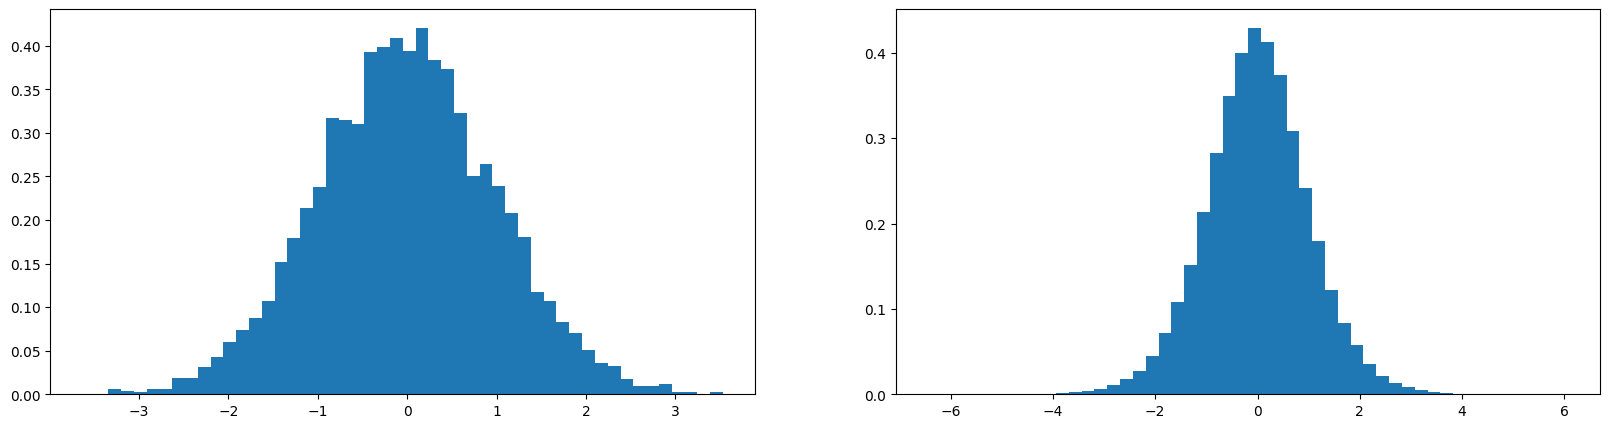

In [7]:
x= torch.randn(1000,10)
w = torch.randn(10,200) / 10**0.5
y= x @ w
print(x.mean(),x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50,density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True);

In [8]:
max_steps = 200000
batch_size=32
lossi=[]
for i in range(max_steps):
    #minibatch construct 
    ix=torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb,Yb =Xtr[ix],Ytr[ix] # batch X,Y

    # foward pass
    emb = C[Xb] #embed the characters into vectors 
    embcat= emb.view(emb.shape[0],-1)
    # linear layer
    hpreact=embcat @ W1 #+ b1 # hidden layer pre-activation

    # BatchNorm Layer
    # ----------------------------------------------------------

    bnmeani=hpreact.mean(0,keepdim=True)
    bnstdi=hpreact.std(0,keepdim=True)
    hpreact= bngain * (hpreact - bnmeani)/ bnstdi + bnbias

    with torch.no_grad():
        bnmean_running=0.999 * bnmean_running + 0.001*bnmeani
        bnstd_running=0.999 * bnstd_running + 0.001*bnstdi
    #-------------------------------------------------------------
    # Non-linearlity  
    h = torch.tanh(hpreact) # hidden layer 
    logits = h @ W2 + b2 # output layer 
    loss = F.cross_entropy(logits,Yb)
    for p in parameters:
        p.grad=None
    loss.backward()

    # update
    lr =0.1 if i< 100000 else 0.01 # step learning rate decay 
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 ==0: # prints every once in a while 
        print(f"{i:7d}/{max_steps:7d}: {loss.item():4f}")
    lossi.append(loss.log10().item())
    # break 

      0/ 200000: 3.323863
  10000/ 200000: 2.032162
  20000/ 200000: 2.567518
  30000/ 200000: 2.012536
  40000/ 200000: 2.244633
  50000/ 200000: 1.889742
  60000/ 200000: 2.078540
  70000/ 200000: 2.368099
  80000/ 200000: 2.291824
  90000/ 200000: 2.023811
 100000/ 200000: 2.367295
 110000/ 200000: 2.313225
 120000/ 200000: 1.641352
 130000/ 200000: 1.931116
 140000/ 200000: 2.223130
 150000/ 200000: 2.002746
 160000/ 200000: 2.099655
 170000/ 200000: 2.494890
 180000/ 200000: 2.019850
 190000/ 200000: 2.170715


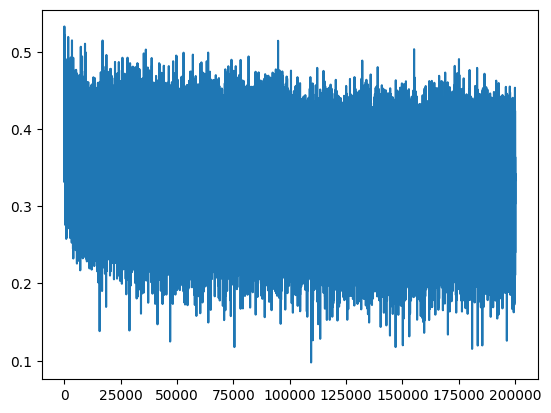

In [9]:
plt.plot(lossi)

In [10]:
# calibrate the batch norm at the end of the training 

with torch.no_grad():
    # pass the training set through
    emb=C[Xtr]
    embcat=emb.view(emb.shape[0],-1)
    hpreact=embcat @ W1 + b1
    # measure the mean/std over the entire training set 
    bnmean = hpreact.mean(0,keepdim=True)
    bnstd=hpreact.std(0, keepdim=True)

NameError: name 'b1' is not defined

In [ ]:
bnmean

tensor([[-2.3355,  0.6776, -0.9133,  1.0163,  1.0865,  1.0938,  1.7437, -2.1208,
          0.5730,  1.4455, -1.6344, -2.7372, -0.4752, -0.1412, -0.0746, -1.1722,
          0.6851, -2.6219, -0.1065,  1.6326, -0.7706, -0.3063,  0.0479,  0.6115,
          1.1173,  0.2427,  2.0500,  0.5831,  0.8527,  1.7680, -0.3625, -0.8356,
         -0.0854, -0.5177, -0.3806, -1.0698, -0.0786,  0.3487, -0.5808,  0.9875,
         -0.4427, -1.3082, -0.2871, -0.2332,  0.6850,  0.6850,  2.0856, -0.7608,
          2.3866,  1.8734,  0.8259,  0.2803,  1.8897,  0.4709,  0.6739, -1.8940,
         -0.0401,  0.4338,  1.3760, -0.8910, -0.4524,  1.1754,  0.5613,  0.6051,
          1.5858,  1.2261, -1.0111,  2.1495, -0.6393,  0.0938, -0.2864, -0.4856,
          0.9632, -1.0461, -2.9990,  0.6391,  1.4327, -0.1590,  0.0941,  0.5253,
          0.2508,  1.2521,  2.0388,  0.6608,  0.0691, -0.0813, -1.6723,  0.2933,
          2.2423, -0.0210, -0.6666,  1.4253, -0.8412, -1.2248, -1.0129,  0.2230,
          0.2112, -0.3226,  

In [ ]:
bnmean_running

tensor([[-2.3539,  0.6872, -0.9001,  1.0159,  1.0894,  1.0862,  1.7389, -2.1357,
          0.5608,  1.4246, -1.6445, -2.7426, -0.4861, -0.1510, -0.0687, -1.1550,
          0.6891, -2.6399, -0.1283,  1.6240, -0.7732, -0.2865,  0.0467,  0.6119,
          1.1172,  0.2433,  2.0542,  0.5778,  0.8515,  1.7729, -0.3741, -0.8385,
         -0.0831, -0.5198, -0.3817, -1.0698, -0.0781,  0.3370, -0.5768,  0.9935,
         -0.4507, -1.3313, -0.2894, -0.2299,  0.6877,  0.6936,  2.0835, -0.7759,
          2.3804,  1.8613,  0.8117,  0.2735,  1.8802,  0.4704,  0.6656, -1.8962,
         -0.0420,  0.4356,  1.3924, -0.8906, -0.4676,  1.1688,  0.5539,  0.6001,
          1.5853,  1.2103, -1.0171,  2.1422, -0.6330,  0.1071, -0.2926, -0.4831,
          0.9506, -1.0144, -2.9925,  0.6268,  1.4404, -0.1574,  0.0955,  0.5159,
          0.2487,  1.2400,  2.0104,  0.6695,  0.0768, -0.0851, -1.6767,  0.2963,
          2.2374, -0.0100, -0.6669,  1.4356, -0.8431, -1.2317, -1.0220,  0.2201,
          0.1928, -0.3261,  

In [ ]:
@torch.no_grad() # this decorator disables gradient tracking 
def split_loss(split):
    x,y ={
        "train": (Xtr,Ytr),
        "val": (Xdev,Ydev),
        "test": (Xte,Yte),
    }[split]
    emb=C[x] # (N, block_size, n_embd)
    embcat=emb.view(emb.shape[0],-1) # concat into (N, block_size * n_embd)
    hpreact= embcat @ W1+b1 #hidden layer pre-activation 
    # hpreact= bngain * (hpreact - hpreact.mean(0,keepdim=True))/ hpreact.std(0,keepdim=True) + bnbias
    hpreact= bngain * (hpreact - bnmean_running)/ bnstd_running + bnbias
    h = torch.tanh(hpreact) #(N,n_hidden)
    logits=h @ W2 + b2 #(N,vocab_size)
    loss=F.cross_entropy(logits, y)
    print(split,loss.item())

split_loss('train')
split_loss('val')

train 2.06659197807312
val 2.1050572395324707


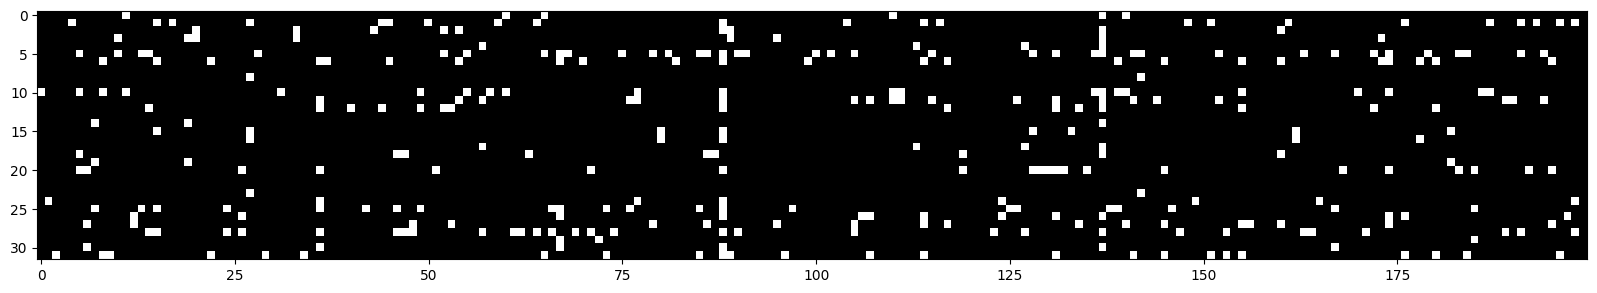

In [ ]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation="nearest")

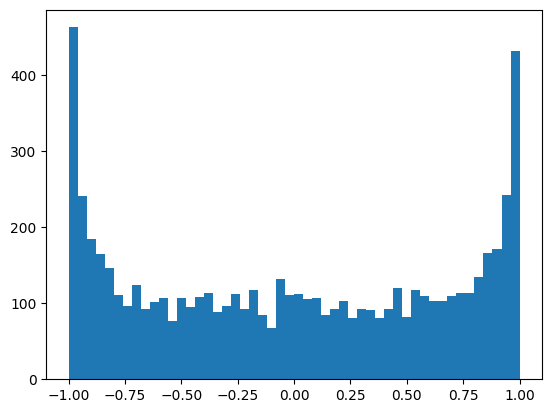

In [ ]:
plt.hist(h.view(-1).tolist(),50);

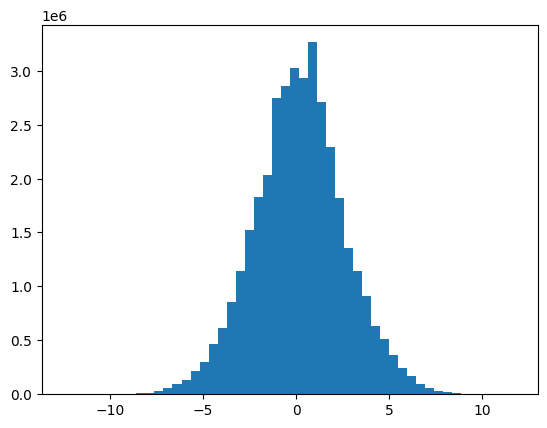

In [ ]:
plt.hist(hpreact.view(-1).tolist(),50);

In [ ]:
logits[0]

tensor([-2.9432,  1.7033, -0.1491, -0.6337, -0.2506,  1.9912, -1.0582, -1.1586,
        -0.0168,  2.3002, -2.0891, -1.5071,  2.9150,  1.6254,  2.9859,  0.7832,
        -0.6382, -3.9366,  1.3895,  1.1865,  0.8465, -1.4758,  0.3450, -2.4001,
        -2.2058,  2.5448, -0.3120], grad_fn=<SelectBackward0>)

In [ ]:
# 4 dimensional example of the issue 
# logits = torch.tensor([0.0,0.0,0.0,0.0])
logits =torch.randn(4)*100
probs=torch.softmax(logits,dim=0)
loss = -probs[2].log()
logits,probs,loss

(tensor([-98.8619, -52.2597,  -4.6713,  17.1330]),
 tensor([0.0000e+00, 7.2968e-31, 3.3923e-10, 1.0000e+00]),
 tensor(21.8043))

In [ ]:
# ideal loss 
-torch.tensor(1/27).log()

tensor(3.2958)

In [ ]:
#sample from the model
g=torch.Generator().manual_seed(2147483647+10)
for _ in range(20):
    out=[]
    context=[0] * block_size #initialize with all....
    while True:
        # foward pass the neural net
        emb=C[torch.tensor([context])] # (1, block_size,n_embd)
        h= torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs= F.softmax(logits, dim=1)
        # sample from the distribution 
        ix=torch.multinomial(probs, num_samples=1,generator=g).item()
        #shift the context window and track the samples 
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token ,break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word 

carpahzarbriq.
shlimrixtts.
lusslaysierricnenddhn.
frtivgqliyah.
farrichaiirdnsleggyu.
bmanvitte.
sants.
lustvi.
vabbuwatth.
giidryxiidh.
sulipsables.
falia.
gtas.
jasfaylahas.
bduricsydustquovozswy.
bjumillassannyks.
sadlusoffordst.
sramsryndlycpllmanraq.
shelseombriyabhda.
ffxrdustvebndvi.
